In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
from config import CASOS, SEMILLAS, TOLERANCIA
from utils import cargar_coordenadas, evaluar_ruta
from runner import ejecutar_experimento

In [3]:
# Cargar datos base
coordenadas = cargar_coordenadas('coords.json')

### **Experimento 1: Greedy Algorithm**

El **Algoritmo Greedy** se implementa en esta práctica como punto de referencia para efectuar la comparativa de resultados con las heuristicas de búsqueda posteriores.

Se basa en la heurística del "vecino más cercano". Partiendo de la estación central (Estación 0), el camión realiza el intercambio de bicicletas para acercar la estación al 50% de su capacidad.

Posteriormente, calcula la distancia Manhattan hacia todas las estaciones pendientes y viaja siempre a la más cercana.

Este proceso iterativo continúa hasta que se han visitado todas le estaciones filtradas y el camión regresa a la Estación 0.

#### **Características**
- **Naturaleza Determinista**: el algoritmo siempre generará la misma ruta para el mismo problema.
- **Ejecución**: se ejecuta *una sola vez* por cada Caso y no es necesario iterar sobre las 5 semillas aleatorias.
- **Evaluación**: realiza 1 sola llamada a la función objetivo.

In [4]:
from algorithms import greedy_algorithm

# Ejecutar Greedy Algorithm
res_greedy = ejecutar_experimento(
    nombre_algoritmo='Greedy Algorithm',
    funcion_algoritmo=greedy_algorithm,
    is_deterministic=True,
    casos=CASOS, semillas=SEMILLAS, tolerancia=TOLERANCIA,
    coordenadas=coordenadas, evaluar_ruta=evaluar_ruta
)


 EXPERIMENTACIÓN: GREEDY ALGORITHM
| Caso   | Score (Ratio)| Kms     | Entropía | Ev. Media| Ev. Mejor | Semilla | Mejor FObj |
--------------------------------------------------------------------------------------------
| Caso 1 |      1.5485 |   23.68 |  15.2903 |      1.0 |         1 |     N/A | ratio      |
| Caso 2 |      1.6087 |   23.77 |  14.7736 |      1.0 |         1 |     N/A | ratio      |
| Caso 3 |      2.4834 |   23.24 |   9.3560 |      1.0 |         1 |     N/A | ratio      |
--------------------------------------------------------------------------------------------


#### **Análisis de Resultados: Greedy Algorithm**

La tabla superior muestra el desempeño del algoritmo Greedy:

- **Eficiencia Espacial (`Kms`)**: en los tres casos, la distancia recorrida es estremadamente baja y constante (*23.2 - 23.7 kms*). De hecho, el *Caso 3* presenta la menor distancia de todas.

- **El Límite del Greedy**: a pesar de tener los mejores kilómetros, el *Caso 3* sufre una penalización masiva en su Función Objetivo, saltando de $\approx 1.5$ a a $2.4834$. En efecto, su *Entropia* se desploma a $9.3560$. El *Caso 3* es un escenario extremo donde casi la mitad de las estaciones están completamente vacías. Como el camión tiene una capacidad limitada ($L=20$) y empieza con pocas bicis (7), es físicamente imposible equilibrar la red en una sola pasada.

- **Insensibilidad a la Función Objetivo (`Mejor FObj`):** En la tabla se observa que la función ganadora es siempre `ratio`. Esto no significa que el Ratio sea matemáticamente superior aquí, sino que es un artefacto de la naturaleza del algoritmo. El Greedy toma sus decisiones de movimiento basándose *únicamente en la distancia mínima*, ignorando por completo la Función Objetivo durante la construcción de la ruta. En consecuencia, sin importar qué fórmula (Ratio, Suma, Exponencial) se utiliza, la ruta física generada será idéntica. Al pasar por el "Árbitro Universal", todas las funciones obtienen exactamente el mismo puntaje y se produce un empate técnico cuádruple. El sistema muestra `ratio` simplemente porque es la *primera función evaluada en la lista*, ganando el desempate por defecto.

---



 EXPERIMENTACIÓN: BÚSQUEDA ALEATORIA
| Caso   | Score (Ratio)| Kms     | Entropía | Ev. Media| Ev. Mejor | Semilla | Mejor FObj |
--------------------------------------------------------------------------------------------
| Caso 1 |      1.8035 |   27.71 |  15.3671 |    100.0 |       100 |     555 | ratio      |
| Caso 2 |      1.8765 |   29.04 |  15.4740 |    100.0 |       100 |     123 | ratio      |
| Caso 3 |      2.7246 |   34.54 |  12.6770 |    100.0 |       100 |     555 | ratio      |
--------------------------------------------------------------------------------------------


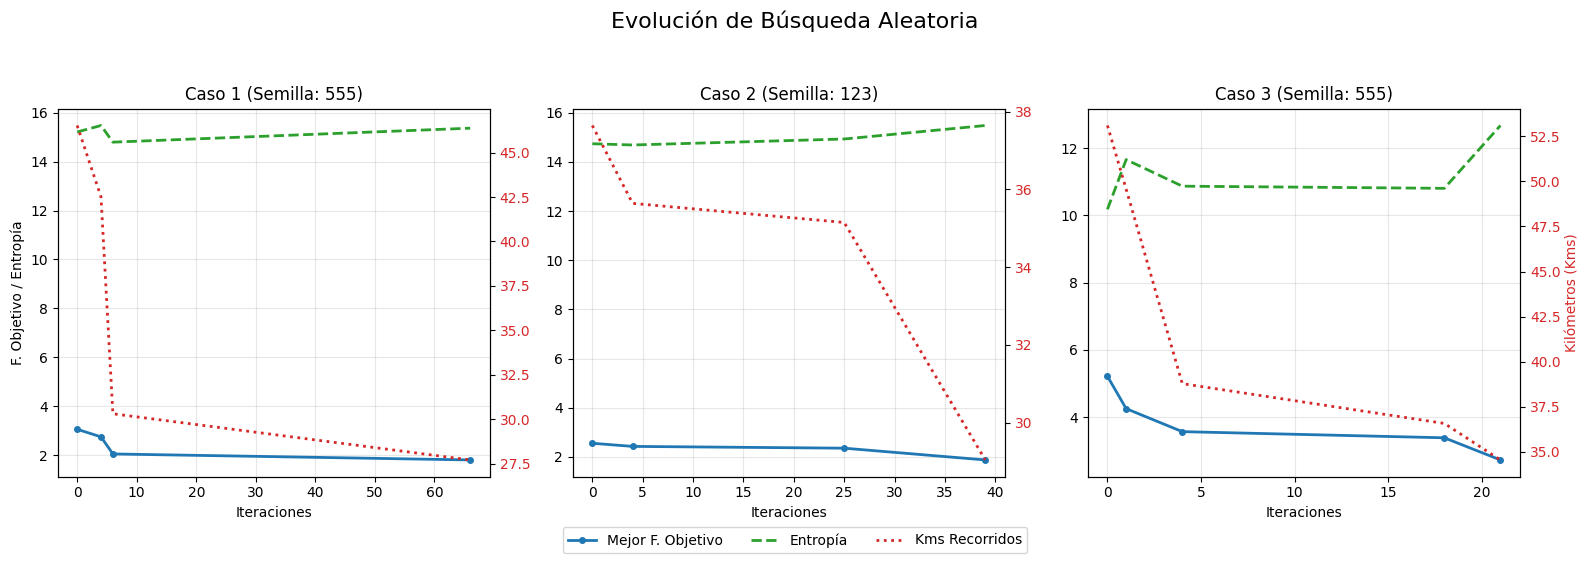

In [5]:
from algorithms import busqueda_aleatoria

# Ejecutar Búsqueda Aleatoria
res_aleatoria = ejecutar_experimento(
    nombre_algoritmo='Búsqueda Aleatoria',
    funcion_algoritmo=busqueda_aleatoria,
    is_deterministic=False,
    casos=CASOS, semillas=SEMILLAS, tolerancia=TOLERANCIA,
    coordenadas=coordenadas, evaluar_ruta=evaluar_ruta,
    max_iter=100
)


 EXPERIMENTACIÓN: BÚSQUEDA MEJOR VECINO
| Caso   | Score (Ratio)| Kms     | Entropía | Ev. Media| Ev. Mejor | Semilla | Mejor FObj |
--------------------------------------------------------------------------------------------
| Caso 1 |      1.5215 |   23.31 |  15.3203 |    262.2 |       221 |     987 | ratio      |
| Caso 2 |      1.5449 |   24.56 |  15.8971 |    320.0 |       441 |     987 | ratio      |
| Caso 3 |      2.1814 |   25.65 |  11.7575 |    482.8 |       595 |     987 | ratio      |
--------------------------------------------------------------------------------------------


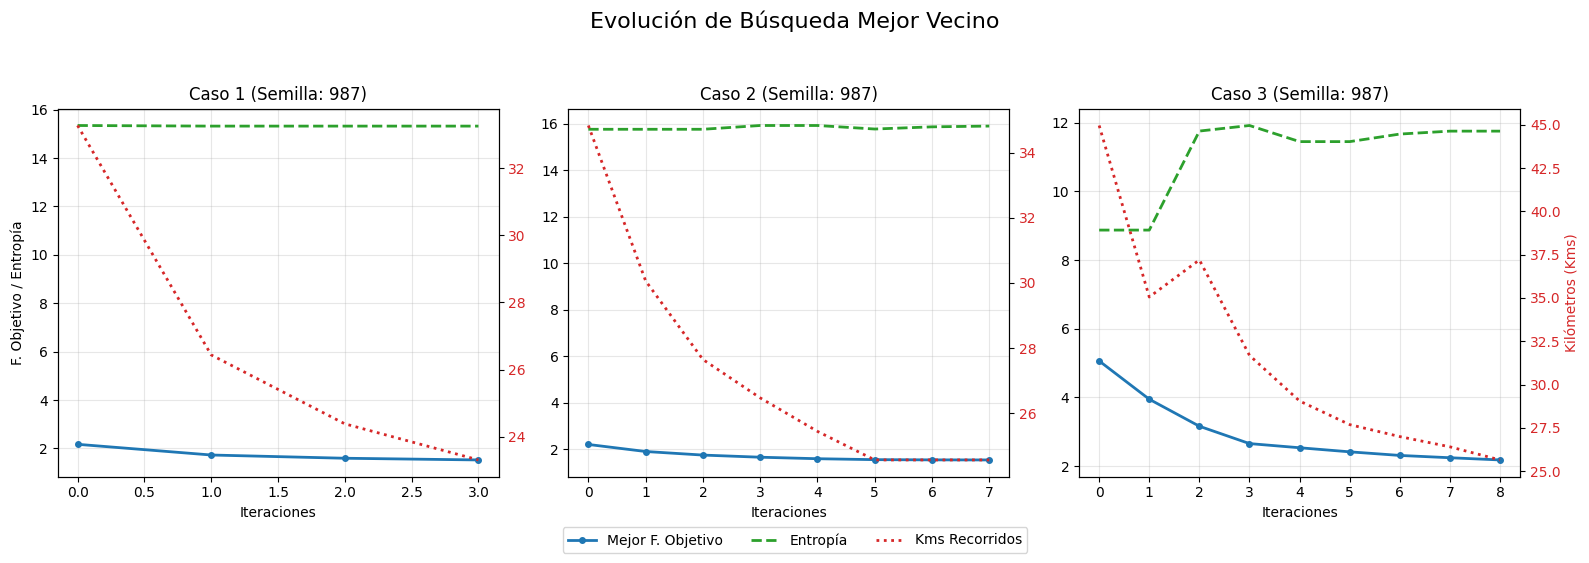

In [6]:
from algorithms import busqueda_local_mejor_vecino

# Ejecutar Búsqueda Mejor Vecino
res_mejor_vecino = ejecutar_experimento(
    nombre_algoritmo='Búsqueda Mejor Vecino',
    funcion_algoritmo=busqueda_local_mejor_vecino,
    is_deterministic=False,
    casos=CASOS, semillas=SEMILLAS, tolerancia=TOLERANCIA,
    coordenadas=coordenadas, evaluar_ruta=evaluar_ruta,
    max_evals=3000
)


 EXPERIMENTACIÓN: BÚSQUEDA PRIMER MEJOR
| Caso   | Score (Ratio)| Kms     | Entropía | Ev. Media| Ev. Mejor | Semilla | Mejor FObj |
--------------------------------------------------------------------------------------------
| Caso 1 |      1.3917 |   21.46 |  15.4165 |    213.1 |       277 |      42 | suma_ponde |
| Caso 2 |      1.5910 |   24.99 |  15.7038 |    220.6 |       257 |      42 | ratio      |
| Caso 3 |      2.2750 |   26.75 |  11.7597 |    280.1 |       269 |     987 | suma_ponde |
--------------------------------------------------------------------------------------------


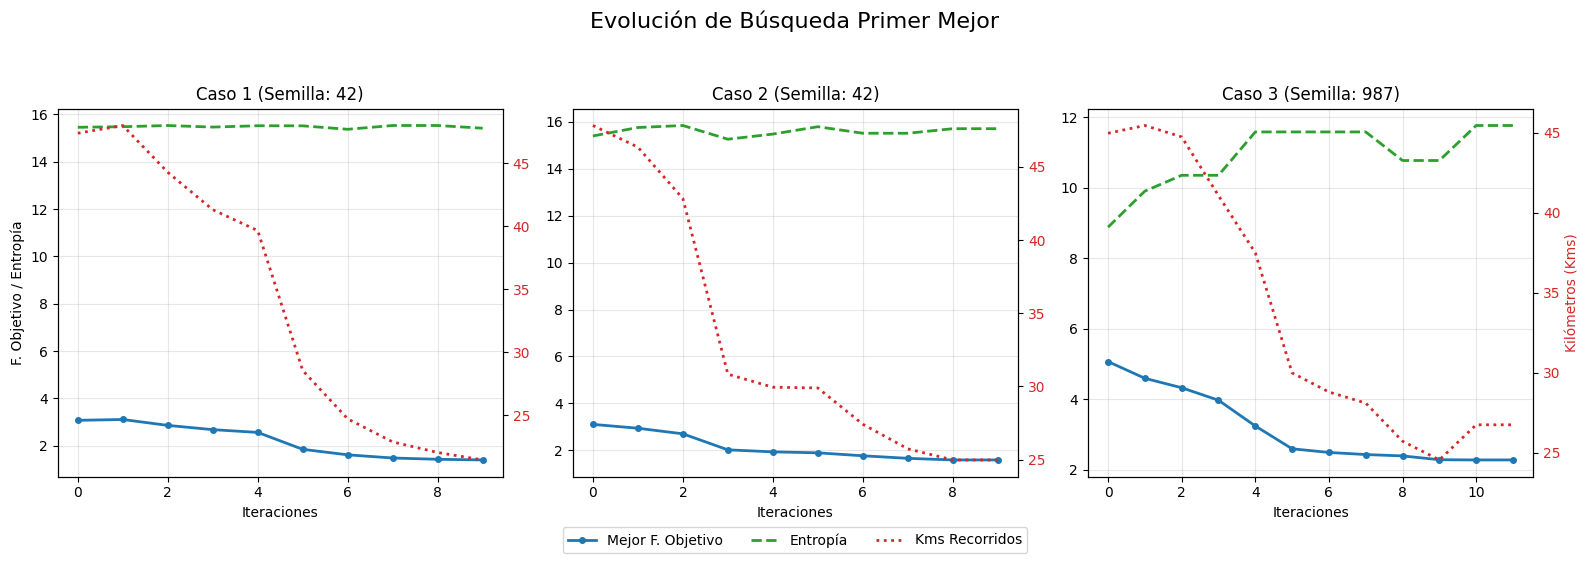

In [7]:
from algorithms import busqueda_local_primer_mejor

# Ejecutar Búsqueda Primer Mejor
res_primer_mejor = ejecutar_experimento(
    nombre_algoritmo='Búsqueda Primer Mejor',
    funcion_algoritmo=busqueda_local_primer_mejor,
    is_deterministic=False,
    casos=CASOS, semillas=SEMILLAS, tolerancia=TOLERANCIA,
    coordenadas=coordenadas, evaluar_ruta=evaluar_ruta,
    max_evals=3000
)